# M2 — The ZTT Analytic Backbone

**retrieve-or-bust · branch `rt-elastic-prototype` · 2026-08-03**

Milestone M2 produces the first *radiative transfer* in this package: the
Zaneveld–Twardowski–Tonizzo model, transcribed into JAX as a differentiable
`Rrs_ZTT(iops, phase_params, geometry, wave)`, plus the standard Gordon baseline it
has to beat.

The headline: **ZTT beats standard Gordon at all three solar zeniths** — and does so
by holding ~3–5% rRMS across the spectrum where Gordon degrades from 2.5% in the
blue to 9% in the red. Getting there required finding one real transcription bug,
and the story of *how* it was found is the most transferable thing in this notebook.

| Module | What landed |
|---|---|
| `robust/rt/ztt.py` | the ZTT model, every function naming its paper equation |
| `robust/rt/baselines.py` | standard Gordon (1988), the comparison model |
| `robust/rt/validation.py` | `rrms` — the one shared accuracy definition |

Earlier notebooks cover the ground this one builds on and does not repeat:
[notebook 1](rt_elastic_coding_1.ipynb) (JAX, autodiff, why float64 matters for the
gradient gate) and [notebook 2](rt_elastic_coding_2.ipynb) (`rrs` vs `Rrs`, the
water/particle split, `B_p`, the held-out splits).

In [1]:
import sys
from pathlib import Path

REPO = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "robust" / "__init__.py").exists()
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp
import numpy as np

from robust.rt import baselines as B
from robust.rt import conventions as C
from robust.rt import validation as V
from robust.rt import ztt as Z
from robust.rt.data import l23 as L
from robust.rt.types import Geometry, IOPs, PhaseParams

print(f"jax {jax.__version__} on {jax.default_backend()}")

jax 0.11.0 on cpu


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# House style, unchanged from notebooks 1-2 so the three read as one set.
INK, INK_MUTED, GRID = "#1a1a1a", "#5c5c5c", "#dcdcdc"
C_A, C_B = "#0072B2", "#D55E00"   # CVD-checked pair (OKLab dE 29-45)
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white", "axes.facecolor": "white",
})
BLUES = mpl.colors.LinearSegmentedColormap.from_list(
    "blues_trunc", plt.cm.Blues(np.linspace(0.35, 0.98, 256)))
print("style set")

style set


## 1. Why an explicit volume scattering function

Every Gordon-family model writes `rrs` as a function of one variable,
`u = bb/(a+bb)`. That is a strong claim: it says two water bodies with the same `u`
reflect identically. They do not — and the reason is the **volume scattering
function**. What reaches a satellite is light scattered through roughly 140°–180°,
and how much of `bb` ends up at those angles depends on *what is doing the
scattering*.

Water molecules and marine particles differ sharply here. ZTT's Equation (10) keeps
them apart:

$$\frac{\beta(\psi)}{b_b} = \frac{P_{bb}(\psi)\, b_{bp} + \beta_w(\psi)}{b_{bp} + b_{bw}}$$

so the model needs `bb_w` and `bb_p` *separately* — which is exactly why M1 refused
to collapse them into `bb`.

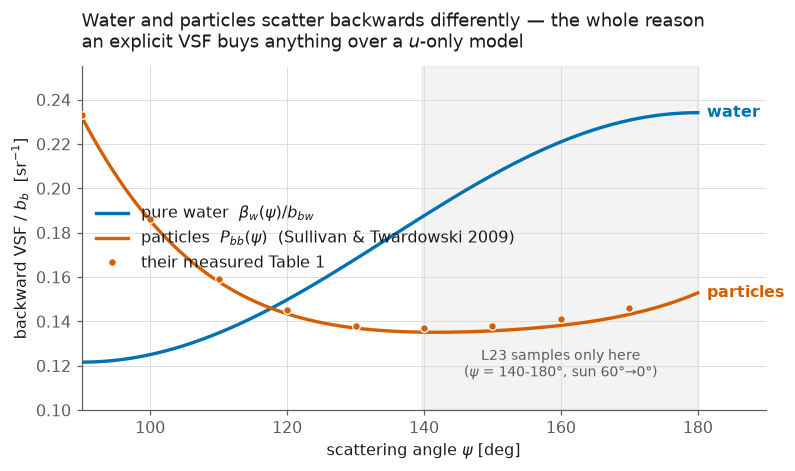

at 180 deg: water 0.234, particles 0.153 sr^-1  -> ratio 1.53x


In [3]:
psi = np.linspace(90.0, 180.0, 400)
water = np.asarray(Z.beta_w_over_bb_w(jnp.asarray(psi)))
particles = np.asarray(Z.P_bb_sullivan(jnp.asarray(psi)))

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(psi, water, color=C_A, lw=2.2, label=r"pure water  $\beta_w(\psi)/b_{bw}$")
ax.plot(psi, particles, color=C_B, lw=2.2,
        label=r"particles  $P_{bb}(\psi)$  (Sullivan & Twardowski 2009)")
ax.plot(Z.P_BB_ST_ANGLES, Z.P_BB_ST_MEAN, "o", color=C_B, ms=5,
        markeredgecolor="white", markeredgewidth=0.8, zorder=3,
        label="their measured Table 1")

ax.annotate("water", xy=(180, water[-1]), xytext=(6, 0), textcoords="offset points",
            color=C_A, fontweight="bold", va="center")
ax.annotate("particles", xy=(180, particles[-1]), xytext=(6, 0),
            textcoords="offset points", color=C_B, fontweight="bold", va="center")

# L23 samples only psi = 140-180 deg (nadir view, sun 60 deg -> 0 deg).
ax.axvspan(139.7, 180.0, color=INK_MUTED, alpha=0.07, zorder=0)
ax.annotate("L23 samples only here\n($\\psi$ = 140-180°, sun 60°→0°)",
            xy=(160, 0.115), color=INK_MUTED, fontsize=9, ha="center")

ax.set_xlabel(r"scattering angle $\psi$ [deg]")
ax.set_ylabel(r"backward VSF / $b_b$  [sr$^{-1}$]")
ax.set_title("Water and particles scatter backwards differently — the whole reason\n"
             "an explicit VSF buys anything over a $u$-only model",
             fontsize=11.5, loc="left", pad=12)
ax.set_xlim(90, 190)
ax.set_ylim(0.10, 0.255)
ax.legend(loc="center left")
fig.tight_layout()
plt.show()

print(f"at 180 deg: water {water[-1]:.3f}, particles {particles[-1]:.3f} sr^-1"
      f"  -> ratio {water[-1]/particles[-1]:.2f}x")

At backscatter, **water returns ~1.5× more of its `bb` toward the sensor than
particles do** (0.234 vs 0.153 sr⁻¹). So clear water and turbid water with identical
`u` genuinely produce different `rrs` — the non-univocality notebook 2 showed
empirically, here as its physical cause.

The shaded band marks the only part of this curve L23 reaches. Nadir viewing gives
ψ = 180° − θs(in-water), so the three solar zeniths probe just ψ = 180°, 158°, and
140° — a narrow slice, and the only phase-function lever the week-1 prototype has.

Two things worth noting about the curves themselves. The water curve is *derived*,
not tabulated: molecular scattering goes as `1 + f cos²ψ`, and normalizing over the
backward hemisphere gives a closed form that lands at 0.234 sr⁻¹ at 180°, against
the 0.23 the literature quotes. The particle curve is measured — several million
field VSFs — and its shape is why "constant backward phase function" in the ZTT
paper means *constant across water types*, not constant across angle.

## 2. What was transcribed, and the two things the papers did not supply

Every term in `ztt.py` names its equation. The assembly is the paper's Equation
(12); Equation (18) adds a Raman term this package omits by scope.

| Term | Equation | Source |
|---|---|---|
| scattering angle ψ, Snell | §2, §2.1 | closed form |
| `Ψ_KLu = 1 + F(ψ)` | (4), (6) | Table A2 `fA` |
| `β(ψ)/bb` | (10) | structure |
| `βw(ψ)/bbw` | §2.3 | **derived here** |
| `Pbb,ST(ψ)` | §4.2 | **Sullivan & Twardowski (2009)** |
| `b̃b` | (11) | structure |
| `µd = M⁺_d × M*_d` | (13)–(17) | Table A2 `e`, `m*_d` |
| `f_L(ψ,λ)` | (31) | Table A3 (91 values) |
| `µ∞` | (8) | **coefficients missing → TT2017** |

**Two coefficient sets were not where the paper said.** Equation (8) states its
sixteen `m` coefficients are "provided in Appendix A, Table A2"; they are not —
Table A2 runs from `m*_d,8` straight into Table A3, and a full-text search finds
`m1`/`m16` only inside Equation (8) itself. The stand-in is the same authors'
antecedent, Twardowski & Tonizzo (2017), whose Table 1 the 2018 text says Equation
(8) "extended". Results here are therefore **ZTT with the TT2017 µ∞**; passing
`mu_inf_coeffs=` restores the published model the moment the authors reply.

And Sullivan & Twardowski's own Table 2 has a **typographic error**: it prints
`a3 = 8.007E−02`, which at ψ = 140° would contribute ~1570 against a tabulated
value of 0.137. Refitting their Table 1 independently gives `a3 ≈ 7.8e-4` while
reproducing their other four coefficients closely, so the intended value is
`8.007E−04`. Corrected in the code, with the reasoning in the docstring.

In [4]:
# The transcription check that matters most: the paper's own worked example.
# Section 2.1: "for theta_s' = 60 deg, theta_s will be 40.3 deg and psi will be
# 139.7 deg for nadir viewing".
_, _, theta_v_paper, psi_60 = Z.geometry_to_paper_angles(Geometry.nadir(jnp.asarray(60.0)))
print(f"paper says theta_s = 40.3 deg  ->  we get {float(Z.in_water_zenith(jnp.asarray(60.0))):.2f}")
print(f"paper says psi     = 139.7 deg ->  we get {float(psi_60):.2f}")
print(f"paper's nadir is theta_v = 180 deg -> we get {float(theta_v_paper):.0f}")
print()
print("That one line exercises Snell refraction, the scattering-angle formula, and")
print("the nadir convention together -- the chain where a reversed sign would give")
print("a wrong-but-plausible BRDF.")

paper says theta_s = 40.3 deg  ->  we get 40.26
paper says psi     = 139.7 deg ->  we get 139.74
paper's nadir is theta_v = 180 deg -> we get 180

That one line exercises Snell refraction, the scattering-angle formula, and
the nadir convention together -- the chain where a reversed sign would give
a wrong-but-plausible BRDF.


## 3. The bug, and why a plausible diagnosis nearly survived

The first run of the accuracy table had ZTT at **21–25% rRMS at 60°** — far worse
than Gordon — and, worse, predicting `rrs` *increasing* with solar zenith when L23
has it falling. A model carrying a real BRDF should not lose to one with no zenith
term at all, so something was wrong.

**The plausible diagnosis.** Fit a single constant `P_bb` per zenith against L23 and
see what the data wants:

| ψ | 180° (sun 0°) | 158° (30°) | 139.7° (60°) |
|---|---|---|---|
| best-fit `P_bb` | 0.148 | 0.134 | 0.092 |

Monotonically falling away from backscatter — the correct physical shape for a
particulate backward phase function — with two of three inside the literature's
0.12–0.16 sr⁻¹. It looked like confirmation that the missing `Pbb(ψ)` was the cause.

It was not. It was a fit absorbing an error elsewhere into the one free parameter
available. When the real `Pbb,ST(ψ)` arrived, the trend was *still* inverted.

**What actually settled it was a quoted number.** §2.7 of the paper states that µd
runs from 0.79 to 0.94 for sun angles 8°–62°. That is a constraint no fit of ours
can bend:

In [5]:
print("  theta_s'   mu_w = cos(above-water)      mu_w = cos(in-water)")
for tsa, quoted in ((8.0, 0.94), (62.0, 0.79)):
    tsw = float(Z.in_water_zenith(jnp.asarray(tsa)))
    out = []
    for mu_w in (np.cos(np.deg2rad(tsa)), np.cos(np.deg2rad(tsw))):
        out.append(1.0 / (0.6 / mu_w + 0.4 / 0.859))
    print(f"   {tsa:4.1f} deg        {out[0]:.3f}                    {out[1]:.3f}"
          f"        (paper: {quoted})")

  theta_s'   mu_w = cos(above-water)      mu_w = cos(in-water)
    8.0 deg        0.933                    0.936        (paper: 0.94)
   62.0 deg        0.573                    0.792        (paper: 0.79)


The paper's `µw` is the cosine of the **in-water** solar zenith. Equation (13) writes
`µw = cos(θs)` — *unprimed*, which §2 defines as in-water — while `H` and `P3` in
the very same expression take the *primed* above-water angle. Mixing them is an easy
mistake and a costly one: it inverted the zenith trend and cost ~13 percentage
points of rRMS at 60°.

The transferable lesson is about *what kind of evidence discriminates*. A parameter
fitted against the same data cannot diagnose a bug in the model that fits it — it
will happily absorb the error and produce a physically sensible-looking answer. An
independently quoted constant can. Both checks are now tests.

## 4. ZTT against Gordon

With `µw` fixed and the real `Pbb,ST(ψ)` in place, on all 3320 L23 scenes at each
of the three solar zeniths:

In [6]:
batch_full = None
try:
    batch_full = L.load_batch()
except Exception as exc:
    print(f"L23 not mounted ($OS_COLOR) — falling back to the cached fixture: {exc}")
batch = batch_full if batch_full is not None else L.load_batch(
    reader=L.npz_reader(REPO / "robust/tests/files/l23_small.npz"))

wave = np.asarray(batch.wave)
zen = batch.zenith
truth = C.Rrs_to_rrs(batch.Rrs)
ztt = Z.rrs_ZTT(batch.iops, batch.phase_params, batch.geometry, batch.wave)
gordon = B.rrs_gordon(batch.iops)

print("overall rRMS [%]      ZTT    Gordon")
for k in (0.0, 30.0, 60.0):
    m = zen == k
    print(f"   solar zenith {k:4.0f}   {float(V.rrms(truth[m], ztt[m])):5.2f}   "
          f"{float(V.rrms(truth[m], gordon[m])):5.2f}")

overall rRMS [%]      ZTT    Gordon


   solar zenith    0    4.30    6.02
   solar zenith   30    4.70    6.20
   solar zenith   60    8.09    9.01


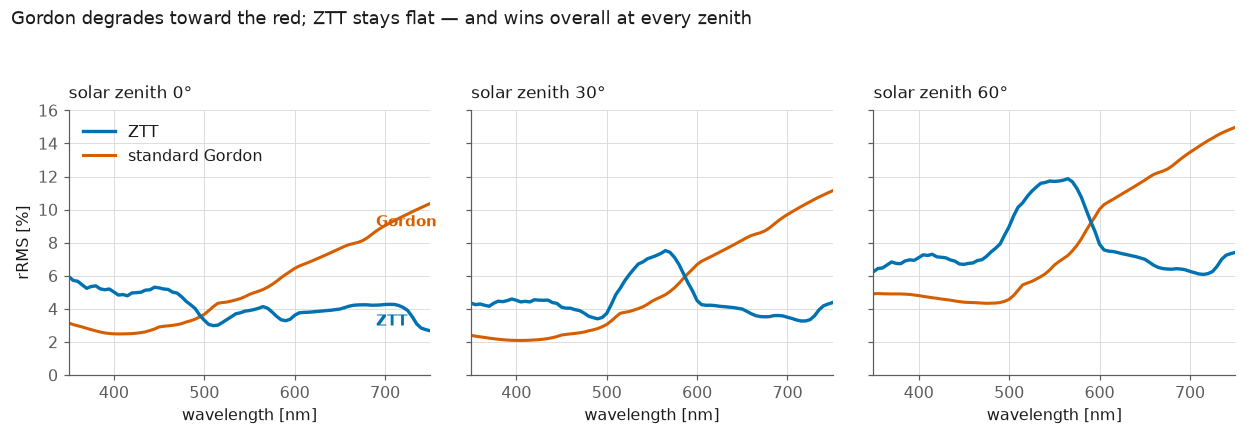

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 4.0), sharey=True)

for ax, k in zip(axes, (0.0, 30.0, 60.0)):
    m = zen == k
    ztt_lad = np.asarray(V.rrms(truth[m], ztt[m], axis=0))
    gor_lad = np.asarray(V.rrms(truth[m], gordon[m], axis=0))
    ax.plot(wave, gor_lad, color=C_B, lw=2.0)
    ax.plot(wave, ztt_lad, color=C_A, lw=2.2)
    ax.set_title(f"solar zenith {k:.0f}°", fontsize=11, loc="left", pad=8)
    ax.set_xlabel("wavelength [nm]")
    ax.set_xlim(wave.min(), wave.max())

axes[0].set_ylabel("rRMS [%]")
axes[0].set_ylim(0, 16)
axes[0].annotate("Gordon", xy=(690, 9.0), color=C_B, fontweight="bold", fontsize=10)
axes[0].annotate("ZTT", xy=(690, 3.0), color=C_A, fontweight="bold", fontsize=10)
axes[0].plot([], [], color=C_A, lw=2.2, label="ZTT")
axes[0].plot([], [], color=C_B, lw=2.0, label="standard Gordon")
axes[0].legend(loc="upper left")

fig.suptitle("Gordon degrades toward the red; ZTT stays flat — and wins overall at "
             "every zenith", fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

The shape is the result, not just the totals. Gordon is genuinely better in the blue
— it was tuned there — but its error climbs steadily toward the red as its single
`u` variable loses purchase. ZTT holds 3–5% across the whole range and takes over
somewhere around 500–550 nm.

That is the case for a physics-anchored backbone in one picture: not that it is
uniformly better, but that its errors do not grow where the parameterisation runs
out of road.

Two blemishes are visible rather than hidden. ZTT carries a **bump near 560 nm**
that grows with zenith — 7% at 30°, 12% at 60° — its single worst region, and the
`µd`/`Ψ_KLu` terms are the natural suspects. And in the deep blue at 60° it is
roughly 2 percentage points behind Gordon.

**What is still wrong.** ZTT over-predicts the zenith effect. Its 60°/0° ratio is
**0.855** against L23's **0.949** — the right sign, but roughly three times too
strong a departure from unity, which is most of what remains of the 60° error. A
test pins that number so it cannot drift, and it is exactly the kind of *structured*
residual M3's emulator is meant to absorb — smooth, systematic, and small.

## 5. The gradient gate

M2 onward, `jax.grad` must agree with central finite differences. This is the
property the future inversion depends on, so it is a hard gate rather than a
report. Notebook 1 §4 measured why it has to run in float64; here is the same
check on the real model, for the four inputs the coding plan names.

In [8]:
jax.config.update("jax_enable_x64", True)
dt = jnp.float64
w3 = jnp.asarray([440.0, 550.0, 660.0], dtype=dt)
bbw3 = jnp.asarray(C.bb_w(w3), dtype=dt)
base = {"a": 0.15, "bb_p": 0.003, "B_p": 0.0126, "theta_s": 30.0}

def scalar(name, value):
    p = dict(base, **{name: value})
    iops = IOPs(a=jnp.full(w3.shape, p["a"], dtype=dt), bb_w=bbw3,
                bb_p=jnp.full(w3.shape, p["bb_p"], dtype=dt))
    return jnp.sum(Z.rrs_ZTT(iops, PhaseParams(B_p=jnp.asarray(p["B_p"], dtype=dt)),
                             Geometry.nadir(jnp.asarray(p["theta_s"], dtype=dt)), w3))

STEPS = np.logspace(-10, -1, 28)
curves = {}
for name in base:
    x = jnp.asarray(base[name], dtype=dt)
    g = float(jax.grad(lambda v, n=name: scalar(n, v))(x))
    errs = []
    for h in STEPS:
        hh = jnp.asarray(h, dtype=dt)
        fd = float((scalar(name, x + hh) - scalar(name, x - hh)) / (2 * hh))
        errs.append(abs(fd - g) / abs(g))
    # A step larger than the variable itself pushes it negative, and the model
    # returns NaN rather than a wrong number. Those steps are not "accurate", they
    # are invalid -- mask them instead of letting argmin find a spurious minimum.
    err = np.array(errs)
    curves[name] = err
    finite = np.isfinite(err)
    j = int(np.flatnonzero(finite)[np.argmin(err[finite])])
    n_invalid = int((~finite).sum())
    note = f"  ({n_invalid} steps invalid: perturbation left the physical domain)" if n_invalid else ""
    print(f"  d/d{name:8s} best relative error {err[j]:.2e} at h = {STEPS[j]:.0e}{note}")
jax.config.update("jax_enable_x64", False)

  d/da        best relative error 7.17e-12 at h = 2e-07


  d/dbb_p     best relative error 7.17e-12 at h = 5e-08  (5 steps invalid: perturbation left the physical domain)
  d/dB_p      best relative error 1.86e-11 at h = 1e-07


  d/dtheta_s  best relative error 2.98e-10 at h = 1e-03


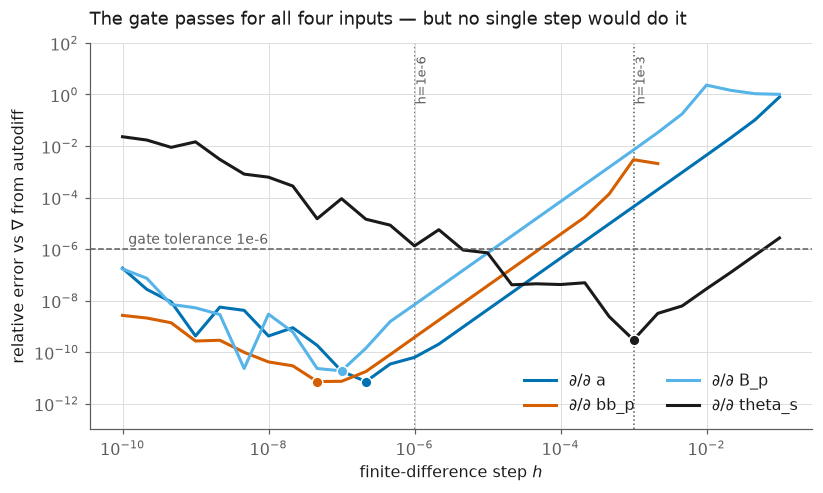

In [9]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))

# Four CATEGORICAL series, so fixed distinct hues rather than a sequential ramp.
# Worst-case separation checked: CVD dE 17.9, normal-vision dE 20.4.
COLOURS = {"a": "#0072B2", "bb_p": "#D55E00", "B_p": "#56B4E9", "theta_s": "#1a1a1a"}

for name, err in curves.items():
    finite = np.isfinite(err)
    j = int(np.flatnonzero(finite)[np.argmin(err[finite])])
    ax.loglog(STEPS, err, lw=2.0, color=COLOURS[name],
              label=f"$\\partial/\\partial$ {name}")
    ax.plot([STEPS[j]], [err[j]], "o", color=COLOURS[name], ms=7,
            markeredgecolor="white", markeredgewidth=1.0, zorder=4)

# The two steps quoted in the text, to make "no single h works" visible.
for h, label in ((1e-6, "1e-6"), (1e-3, "1e-3")):
    ax.axvline(h, color=INK_MUTED, lw=1.0, ls=":", zorder=0)
    ax.text(h, 30.0, f" h={label}", color=INK_MUTED, fontsize=8.5, rotation=90,
            va="top")

ax.axhline(1e-6, color=INK_MUTED, lw=1, ls="--")
ax.text(1.2e-10, 1.6e-6, "gate tolerance 1e-6", color=INK_MUTED, fontsize=9)
ax.set_xlabel("finite-difference step $h$")
ax.set_ylabel(r"relative error vs $\nabla$ from autodiff")
ax.set_title("The gate passes for all four inputs — but no single step would do it",
             fontsize=11.5, loc="left", pad=12)
ax.set_ylim(1e-13, 1e2)
ax.legend(loc="lower right", ncol=2)
fig.tight_layout()
plt.show()

All four dip well below the 1e-6 gate, so the gate passes. The practical point is
where their minima sit: they span roughly four orders of magnitude in `h`, and **no
single step clears the gate for all four**. At `h` = 1e-6 the three IOP-like
variables are at 1e-10 or better but `theta_s` misses at 1.3e-6; at `h` = 1e-3
`theta_s` is superb at 3e-10 while `a`, `bb_p`, and `B_p` fail by 4e-5 to 7e-3.

The reason is scale, not physics: `theta_s` is O(30) while the others are O(1e-3) to
O(0.1), so the same *absolute* step is a wildly different *relative* perturbation.
The `bb_p` curve stops early for a related reason worth stating: a step larger than
`bb_p` itself pushes it negative, and the model returns NaN rather than a wrong
number. Those steps are not inaccurate, they are invalid — and a first pass at this
figure let `argmin` pick one of them as the "best" step, which is why the sweep now
masks non-finite results explicitly.
The test suite therefore parameterises the step per variable. Had it used one global
`h`, two of the four would have failed and the failure would have looked like a
broken gradient rather than a badly chosen step.

This is the same lesson as notebook 1 §4, one level up: there, choosing float32 made
the finite difference test the dtype; here, choosing one step size would make it test
the step.

## 6. Where this leaves M3

**M2 is done.** 169 tests pass; `ruff check` and `ruff format --check` are clean.
The backbone is differentiable, gate-passing, and beats standard Gordon at all three
solar zeniths on the full L23 set.

What M3 inherits, concretely:

- `Rrs_ZTT` with the signature `forward` will keep, so the hybrid is
  `Rrs_ZTT + ΔRrs` with no interface change.
- A residual that is **structured, not noise**: ZTT is 3–5% across the spectrum with
  a systematic blue-end deficit and a zenith effect over-predicted by ~3×. Smooth,
  low-dimensional, and small — which is the case for a light emulator rather than a
  large one.
- `rrms` as a differentiable JAX function, ready to serve as the training loss, and
  the Gordon baseline the M3 gate is stated against.

Two loose ends carried forward: Equation (8)'s sixteen coefficients (emailed to the
authors; `mu_inf_coeffs=` swaps them in), and the reminder from notebook 2 that L23
spans only a 1.75× slice of `B_p`, so none of this demonstrates generalisation
across phase-function *shape*. That wait is M5's HydroLight runs.